# GraphSAGE Training v2 — Hard Negative Mining + Full Dataset
**MSc Thesis: Graph-Augmented Table Retrieval in RAG Pipelines**

### Changes from v1:
- **Hard negative mining**: mines 8 confusing tables per sample from BGE query similarity
- **Larger dataset**: 5000 train + 500 val (increased from 3000/300)
- **Hard-negative-aware batching**: each batch includes anchor + its hardest negatives

### Setup:
1. **Session options → Accelerator → GPU T4 x2**, **Internet → On**
2. Click **Run All** — takes ~30 min total

In [1]:
# Step 1: Clone repo and install dependencies
import os, sys

REPO_URL = 'https://github.com/meetp2022/Research_Thesis_RAG_Graph_Augmented_Table.git'
REPO_DIR = '/kaggle/working/graph-table-rag'

if not os.path.exists(REPO_DIR):
    os.system(f'git clone {REPO_URL} {REPO_DIR}')
else:
    os.system(f'cd {REPO_DIR} && git pull')

os.chdir(REPO_DIR)
sys.path.insert(0, REPO_DIR)
print(f'Working dir: {os.getcwd()}')

Cloning into '/kaggle/working/graph-table-rag'...


Working dir: /kaggle/working/graph-table-rag


In [2]:
# Install dependencies
os.system('pip install torch-geometric -q')
os.system('pip install sentence-transformers faiss-cpu networkx loguru rich pyyaml "datasets>=2.14,<3" -q')
print('Dependencies installed')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 15.7 MB/s eta 0:00:00
Dependencies installed


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
s3fs 2026.2.0 requires fsspec==2026.2.0, but you have fsspec 2024.6.1 which is incompatible.
tpot 1.1.0 requires dill>=0.3.9, but you have dill 0.3.8 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.6.1 which is incompatible.


In [3]:
# Step 2: Verify GPU
import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

PyTorch: 2.10.0+cu128
CUDA: True
GPU: Tesla T4
VRAM: 15.6 GB


In [4]:
# Step 3: Load config and data
from src.utils.config import load_config
from src.data.dataset_loader import load_dataset_by_name

config = load_config(pipeline='graph')
config['training'] = {
    'lr': 0.0001,
    'temperature': 0.07,
    'epochs': 25,              # More epochs for larger dataset
    'batch_size': 64,
    'patience': 7,             # More patience with hard negatives (loss is noisier)
    'save_dir': 'models/graph_encoder',
    'num_hard_negatives': 8,   # NEW: mine 8 hard negatives per sample
}

# 5000 samples — good balance of quality and speed (~20 min embedding)
TRAIN_SAMPLES = 5000
VAL_SAMPLES = 500

print(f'Loading WikiTQ (train: {TRAIN_SAMPLES}, val: {VAL_SAMPLES})...')
train_records = load_dataset_by_name('wikitq', split='train', max_samples=TRAIN_SAMPLES)
val_records   = load_dataset_by_name('wikitq', split='validation', max_samples=VAL_SAMPLES)
print(f'Train: {len(train_records)} | Val: {len(val_records)}')

2026-04-16 16:48:04.234 | INFO     | src.utils.config:load_config:51 - Loaded pipeline config: configs/pipeline3_graph.yaml
2026-04-16 16:48:04.235 | INFO     | src.data.dataset_loader:load_wikitablequestions:119 - Loading WikiTableQuestions (train split)...


Loading WikiTQ (train: 5000, val: 500)...


Generating train split:   0%|          | 0/11321 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/4344 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2831 [00:00<?, ? examples/s]

2026-04-16 16:48:13.785 | INFO     | src.data.dataset_loader:load_wikitablequestions:146 - Loaded 5000 WikiTableQuestions records (train)
2026-04-16 16:48:13.787 | INFO     | src.data.dataset_loader:load_wikitablequestions:119 - Loading WikiTableQuestions (validation split)...
2026-04-16 16:48:14.100 | INFO     | src.data.dataset_loader:load_wikitablequestions:146 - Loaded 500 WikiTableQuestions records (validation)


Train: 5000 | Val: 500


In [5]:
# Step 4: Train with hard negative mining
import time
from src.graph.train import ContrastiveTrainer

trainer = ContrastiveTrainer.from_config(config)
print(f'Device: {trainer.device}')
print(f'Hard negatives: {trainer.num_hard_negatives}')

start = time.time()
result = trainer.train(train_records, val_records)
elapsed = time.time() - start

print(f'\n{result.summary()}')
print(f'Total wall time: {elapsed/60:.1f} min')

2026-04-16 16:48:27.353 | DEBUG    | src.graph.graph_embedding:__init__:97 - TableGraphEncoder: 2 SAGEConv layers, 774→256→768, dropout=0.1, pool=mean
2026-04-16 16:48:27.614 | INFO     | src.graph.train:_prepare_data:273 - Preparing data: 5000 records...
2026-04-16 16:48:27.620 | DEBUG    | src.graph.table_to_graph:table_to_graph:177 - Built graph for record nt-0: 78 nodes, 200 edges
2026-04-16 16:48:27.622 | DEBUG    | src.graph.table_to_graph:table_to_graph:177 - Built graph for record nt-1: 109 nodes, 289 edges
2026-04-16 16:48:27.625 | DEBUG    | src.graph.table_to_graph:table_to_graph:177 - Built graph for record nt-4: 247 nodes, 680 edges
2026-04-16 16:48:27.626 | DEBUG    | src.graph.table_to_graph:table_to_graph:177 - Built graph for record nt-5: 49 nodes, 119 edges
2026-04-16 16:48:27.628 | DEBUG    | src.graph.table_to_graph:table_to_graph:177 - Built graph for record nt-6: 197 nodes, 528 edges
2026-04-16 16:48:27.631 | DEBUG    | src.graph.table_to_graph:table_to_graph:177 

Device: cuda
Hard negatives: 8


2026-04-16 16:48:27.816 | DEBUG    | src.graph.table_to_graph:table_to_graph:177 - Built graph for record nt-128: 49 nodes, 119 edges
2026-04-16 16:48:27.817 | DEBUG    | src.graph.table_to_graph:table_to_graph:177 - Built graph for record nt-129: 41 nodes, 98 edges
2026-04-16 16:48:27.818 | DEBUG    | src.graph.table_to_graph:table_to_graph:177 - Built graph for record nt-131: 86 nodes, 224 edges
2026-04-16 16:48:27.820 | DEBUG    | src.graph.table_to_graph:table_to_graph:177 - Built graph for record nt-133: 181 nodes, 493 edges
2026-04-16 16:48:27.823 | DEBUG    | src.graph.table_to_graph:table_to_graph:177 - Built graph for record nt-134: 225 nodes, 621 edges
2026-04-16 16:48:27.823 | DEBUG    | src.graph.table_to_graph:table_to_graph:177 - Built graph for record nt-135: 36 nodes, 84 edges
2026-04-16 16:48:27.826 | DEBUG    | src.graph.table_to_graph:table_to_graph:177 - Built graph for record nt-136: 166 nodes, 448 edges
2026-04-16 16:48:27.828 | DEBUG    | src.graph.table_to_graph

Batches:   0%|          | 0/479 [00:00<?, ?it/s]

2026-04-16 16:50:53.585 | INFO     | src.graph.feature_extraction:convert_batch:398 - Embedded 1400/5000 graphs (1400 Data objects built)


...

Batches:   0%|          | 0/470 [00:00<?, ?it/s]

2026-04-16 16:57:25.045 | INFO     | src.graph.feature_extraction:convert_batch:398 - Embedded 400/500 graphs (400 Data objects built)


Batches:   0%|          | 0/198 [00:00<?, ?it/s]

2026-04-16 16:57:32.489 | INFO     | src.graph.feature_extraction:convert_batch:398 - Embedded 500/500 graphs (500 Data objects built)
2026-04-16 16:57:32.490 | INFO     | src.graph.feature_extraction:convert_batch:403 - Batch conversion complete: 500 PyG Data objects
2026-04-16 16:57:33.052 | DEBUG    | src.pipelines.shared.query_encoder:encode:121 - Encoded 500 queries → shape (500, 768)
2026-04-16 16:57:33.053 | INFO     | src.graph.train:_prepare_data:303 - Prepared 500 graphs + (500, 768) query embeddings
2026-04-16 16:57:33.397 | INFO     | src.graph.train:_save_cache:251 - Cached PyG data to models/graph_encoder/cache/pyg_ef0029a9a203.pkl (236.9 MB)
2026-04-16 16:57:33.717 | INFO     | src.graph.train:mine_hard_negatives:124 - Mined 8 hard negatives per sample (avg hard-neg similarity: 0.695)
2026-04-16 16:57:33.718 | INFO     | src.graph.train:train:519 - Starting contrastive training: 25 epochs, lr=0.0001, temp=0.07, batch=64, hard_negatives=8
2026-04-16 16:57:55.511 | INFO   


Training complete: 21 epochs, best val loss=2.1174, final train loss=1.6951, time=998.5s
Total wall time: 16.6 min


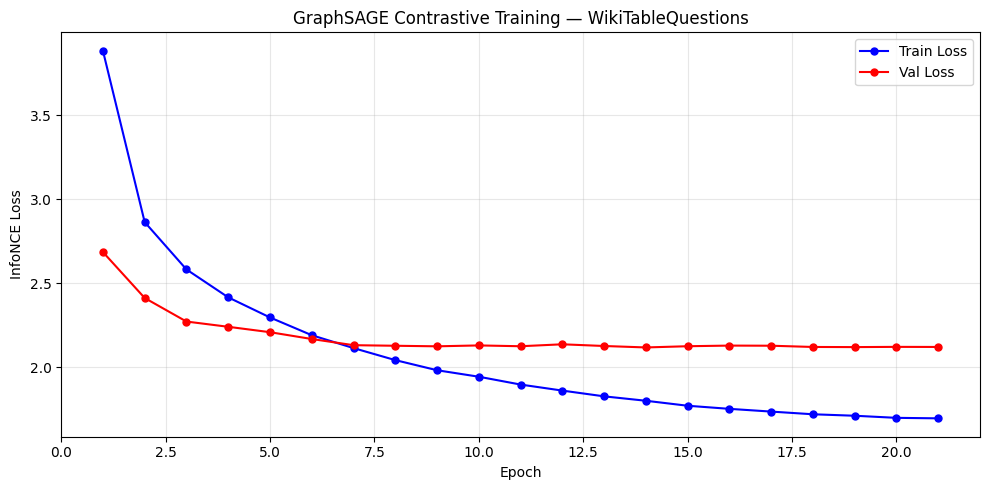

Best val loss: 2.1174


In [6]:
# Step 5: Plot training curve
import matplotlib.pyplot as plt

epochs     = [h['epoch']      for h in result.history]
train_loss = [h['train_loss'] for h in result.history]
val_loss   = [h['val_loss']   for h in result.history]

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_loss, 'b-o', label='Train Loss', markersize=5)
plt.plot(epochs, val_loss,   'r-o', label='Val Loss',   markersize=5)
plt.xlabel('Epoch'); plt.ylabel('InfoNCE Loss')
plt.title('GraphSAGE Contrastive Training — WikiTableQuestions')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
os.makedirs('docs/figures', exist_ok=True)
plt.savefig('/kaggle/working/training_curve.png', dpi=150)
plt.show()
print(f'Best val loss: {result.best_val_loss:.4f}')

In [7]:
# Step 6: Copy outputs to /kaggle/working for download
import shutil, json

shutil.copy('models/graph_encoder/best_encoder.pt', '/kaggle/working/best_encoder.pt')

# Save training log manually (the CLI script creates this, but we ran directly)
log_data = {
    'dataset': 'wikitq', 'split': 'train',
    'num_train': len(train_records), 'num_val': len(val_records),
    'config': config['training'],
    'result': {
        'epochs_completed': result.epochs_completed,
        'best_val_loss': result.best_val_loss,
        'final_train_loss': result.final_train_loss,
        'time_seconds': result.training_time_seconds,
    },
    'history': result.history,
}
with open('/kaggle/working/training_log.json', 'w') as f:
    json.dump(log_data, f, indent=2)

print('Output files ready for download (right panel → Output):')
for f in ['/kaggle/working/best_encoder.pt',
          '/kaggle/working/training_log.json',
          '/kaggle/working/training_curve.png']:
    if os.path.exists(f):
        size = os.path.getsize(f) / 1e6
        print(f'  {f}  ({size:.1f} MB)')

print('\nAfter downloading, place best_encoder.pt at:')
print('  models/graph_encoder/best_encoder.pt')

Output files ready for download (right panel → Output):
  /kaggle/working/best_encoder.pt  (3.2 MB)
  /kaggle/working/training_log.json  (0.0 MB)
  /kaggle/working/training_curve.png  (0.1 MB)

After downloading, place best_encoder.pt at:
  models/graph_encoder/best_encoder.pt


In [8]:
# Step 7: Quick retrieval check
from src.pipelines.graph_augmented.pipeline import GraphAugmentedPipeline

test_records = val_records[:20]
pipeline = GraphAugmentedPipeline.from_config(config, fallback_to_mock=True)
pipeline.index(test_records)

correct = 0
for rec in test_records[:10]:
    res = pipeline.retriever.retrieve(rec.question, top_k=1)
    hit = res[0].record_id == rec.id if res else False
    correct += int(hit)
    print(f'{"✅" if hit else "❌"} score={res[0].score:.3f} | {rec.question[:70]}')

print(f'\nR@1 (10 samples): {correct}/10 = {correct*10}%')

2026-04-16 17:05:06.662 | INFO     | src.pipelines.graph_augmented.pipeline:from_config:247 - Building Graph-Augmented Pipeline from config...
2026-04-16 17:05:06.674 | DEBUG    | src.graph.graph_embedding:__init__:97 - TableGraphEncoder: 2 SAGEConv layers, 774→256→768, dropout=0.1, pool=mean
2026-04-16 17:05:06.684 | INFO     | src.graph.graph_embedding:load:264 - Loaded TableGraphEncoder from models/graph_encoder/best_encoder.pt
2026-04-16 17:05:06.686 | INFO     | src.pipelines.graph_augmented.pipeline:from_config:258 - Loaded trained GraphSAGE from models/graph_encoder/best_encoder.pt
2026-04-16 17:05:06.687 | DEBUG    | src.pipelines.shared.vector_store:__init__:70 - FaissVectorStore initialised: dim=768, index=IndexFlatIP, normalize=True
2026-04-16 17:05:06.687 | DEBUG    | src.pipelines.shared.llm_client:__init__:66 - OllamaClient initialised: model=mistral, url=http://localhost:11434, temp=0.0
2026-04-16 17:05:06.691 | WARNING  | src.pipelines.shared.llm_client:is_available:106

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/53 [00:00<?, ?it/s]

2026-04-16 17:05:09.830 | INFO     | src.graph.feature_extraction:convert_batch:398 - Embedded 20/20 graphs (20 Data objects built)
2026-04-16 17:05:09.831 | INFO     | src.graph.feature_extraction:convert_batch:403 - Batch conversion complete: 20 PyG Data objects
2026-04-16 17:05:09.832 | INFO     | src.pipelines.graph_augmented.pipeline:index:124 -   Feature extraction: 3.10s
2026-04-16 17:05:09.933 | DEBUG    | src.graph.graph_embedding:encode_batch:206 - Encoded 20/20 graphs
2026-04-16 17:05:09.934 | INFO     | src.graph.graph_embedding:encode_batch:213 - Encoded 20 graphs → table embeddings shape: torch.Size([20, 768])
2026-04-16 17:05:09.935 | INFO     | src.pipelines.graph_augmented.pipeline:index:129 -   Graph encoding:     0.10s
2026-04-16 17:05:09.936 | DEBUG    | src.pipelines.shared.vector_store:reset:294 - Vector store reset
2026-04-16 17:05:09.936 | DEBUG    | src.pipelines.shared.vector_store:add:159 - Added 20 vectors to index (total: 20)
2026-04-16 17:05:09.937 | INFO 

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-04-16 17:05:10.912 | DEBUG    | src.pipelines.shared.query_encoder:encode:121 - Encoded 1 queries → shape (1, 768)
2026-04-16 17:05:10.912 | DEBUG    | src.pipelines.shared.retriever:retrieve:126 - Retrieved 1 tables for query: 'which team won previous to crettyard?'...
2026-04-16 17:05:10.926 | DEBUG    | src.pipelines.shared.query_encoder:encode:121 - Encoded 1 queries → shape (1, 768)
2026-04-16 17:05:10.927 | DEBUG    | src.pipelines.shared.retriever:retrieve:126 - Retrieved 1 tables for query: 'how many more passengers flew to los angeles than to saskato'...
2026-04-16 17:05:10.940 | DEBUG    | src.pipelines.shared.query_encoder:encode:121 - Encoded 1 queries → shape (1, 768)
2026-

✅ score=0.196 | which team won previous to crettyard?
✅ score=0.204 | how many more passengers flew to los angeles than to saskatoon from ma
✅ score=0.171 | after winning on four credits with a full house, what is your payout?
✅ score=0.289 | which players played the same position as ardo kreek?
❌ score=0.204 | which athlete was from south korea after the year 2010?
✅ score=0.295 | what was the venue when he placed first?
❌ score=0.242 | who ranked right after turkey?
✅ score=0.296 | what is the total population in dzhebariki-khaya?
✅ score=0.256 | who was the top ranked competitor in this race?
❌ score=0.294 | what was the number of silver medals won by ukraine?

R@1 (10 samples): 7/10 = 70%
